## Model Loading

In [42]:
import torch
from pathlib import Path
import sys

# 루트 경로 추가 (Model, dataset 로딩 위해)
root_dir = Path('/storage/personal/eungyeop/LLM/tabular/ProtoLLM')
sys.path.append(str(root_dir))

from models.TabularFLM_S import Model
from dataset.data_dataloaders import prepare_embedding_dataloaders
from utils.util import fix_seed
from ot.batch import solve_gromov_batch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#ckpt_path = "/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/heart/Pre/ngraphs-8_nnodes-8_gdim-128_nheads-1_nbasis-2_basis-ind_attn-gat_v1_fgw_alpha-1_vq_beta-0.3_kl_gamma-0.2_target_data-Medicaldataset_description-asdasd/42/best.pt"
#ckpt_path = "/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/heart/Pre/ngraphs-8_nnodes-8_gdim-128_nheads-1_nbasis-2_basis-ind_attn-gat_v1_fgw_alpha-1_vq_beta-0.3_kl_gamma-0.2_target_data-Medicaldataset_description-asdasdasdasd/42/best.pt"
ckpt_path = "/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/heart/Pre/ngraphs-8_nnodes-8_gdim-128_nheads-1_nbasis-2_basis-ind_attn-gat_v1_fgw_alpha-1_vq_beta-0.3_kl_gamma-0.2_target_data-Medicaldataset_description-asdasdasdasdasd/42/best.pt"
# checkpoint load
ckpt = torch.load(ckpt_path, map_location=device)
args = ckpt['args']

# 모델 초기화
model = Model(
    args,
    args.input_dim,
    args.hidden_dim,
    args.output_dim,
    args.dropout_rate,
    args.llm_model,
    experiment_id="viz",
    mode="viz"
).to(device)

sd = ckpt['model_state_dict']
missing, unexpected = model.load_state_dict(sd, strict=False)
print("Missing keys:", missing)
print("Unexpected keys:", unexpected)

model.eval()


Missing keys: []
Unexpected keys: []


Model(
  (basis_layers): ModuleList(
    (0-1): 2 x BasisGATLayer_IND(
      (attn_dropout): Dropout(p=0.1, inplace=False)
      (q_proj_list): ModuleList(
        (0): Linear(in_features=768, out_features=768, bias=True)
      )
      (k_proj_list): ModuleList(
        (0): Linear(in_features=768, out_features=768, bias=True)
      )
      (v_proj_list): ModuleList(
        (0): Linear(in_features=768, out_features=768, bias=True)
      )
      (attn_proj_list): ModuleList(
        (0): Linear(in_features=2304, out_features=1, bias=True)
      )
      (edge_update): Sequential(
        (0): Linear(in_features=1536, out_features=768, bias=True)
        (1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (2): ReLU()
        (3): Linear(in_features=768, out_features=768, bias=True)
      )
    )
  )
  (basis_layer_norms): ModuleList(
    (0-1): 2 x LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (sheads): ModuleList(
    (0): Sequential(
      (0): LayerNorm((7

## Source Loading

In [43]:
args2 = args
fix_seed(args2.random_seed)

# source_data가 리스트일 경우 여러 개
sources = args2.source_data if isinstance(args2.source_data, (list, tuple)) else [args2.source_data]

loaders = {}
for src in sources:
    print(f"Loading dataloader for source: {src}")
    res = prepare_embedding_dataloaders(args2, src)
    tr, va, te = res['loaders']
    
    from torch.utils.data import ConcatDataset, DataLoader
    ds = ConcatDataset([tr.dataset, va.dataset, te.dataset])
    
    loaders[src] = DataLoader(ds, batch_size=32, shuffle=False)


Loading dataloader for source: heart
Loading embeddings from: /storage/personal/eungyeop/dataset/embedding/tabular_embeddings_carte/gpt2_mean/embedding_heart.pkl
Training data size: 550
Validation data size: 184
Test data size: 184


In [44]:
import torch.nn.functional as F

@torch.no_grad()
def extract_basis_attention_and_embedding(model, batch):
    batch = {k: (v.to(device) if isinstance(v, torch.Tensor) else v) for k, v in batch.items()}

    # desc/name/value gather
    desc_embeddings, name_embeddings, value_embeddings = [], [], []
    if all(k in batch for k in ['cat_name_embeddings', 'cat_value_embeddings', 'cat_desc_embeddings']):
        desc_embeddings.append(batch['cat_desc_embeddings'])
        name_embeddings.append(batch['cat_name_embeddings'])
        value_embeddings.append(batch['cat_value_embeddings'])
    if all(k in batch for k in ['num_prompt_embeddings', 'num_desc_embeddings']):
        desc_embeddings.append(batch['num_desc_embeddings'])
        name_embeddings.append(batch['num_name_embeddings'])
        value_embeddings.append(batch['num_prompt_embeddings'])

    desc = torch.cat(desc_embeddings, dim=1)
    name = torch.cat(name_embeddings, dim=1)
    value = torch.cat(value_embeddings, dim=1)

    # CLS + value token concat
    x_basis = torch.cat([model.basis_cls.expand(value.size(0), 1, model.input_dim), value], dim=1)

    attentions = []

    # each BasisGAT layer
    for l in range(model.num_basis_layers):
        norm_x = model.basis_layer_norms[l](x_basis)
        basis_outputs, att = model.basis_layers[l](name, norm_x)
        
        # attention shape: [B, H, T, T]
        attentions.append(att[0].detach().cpu().numpy())
        
        x_basis = x_basis + basis_outputs.reshape(x_basis.size(0), x_basis.size(1), model.input_dim)

    embeddings = x_basis[0].detach().cpu().numpy()  # CLS+tokens, shape [T, D]
    return attentions, embeddings

import matplotlib.pyplot as plt
import numpy as np
import os
def plot_attention_heatmap(att, feature_names, title):
    H, T, _ = att.shape
    # ---- Bigger, readable figure ----
    figsize_x = max(8, T * 0.8)  # at least width 8
    figsize_y = max(4, H * 3)    # at least height 4

    plt.figure(figsize=(figsize_x, figsize_y))

    for h in range(H):
        plt.subplot(1, H, h+1)
        plt.imshow(att[h], cmap='viridis')

        plt.xticks(range(T), feature_names, rotation=90, fontsize=10)
        plt.yticks(range(T), feature_names, fontsize=10)

        plt.title(f"{title} - Head {h}", fontsize=14)
        plt.colorbar()

    plt.tight_layout()
    plt.show()
from sklearn.manifold import TSNE

def plot_embedding_tsne(emb):
    # emb: [T, D]
    tsne = TSNE(n_components=2, perplexity=10, learning_rate=100)
    xy = tsne.fit_transform(emb)

    plt.figure(figsize=(6, 6))
    plt.scatter(xy[:, 0], xy[:, 1])
    for i in range(xy.shape[0]):
        plt.text(xy[i,0], xy[i,1], str(i), fontsize=8)
    plt.title("t-SNE of embeddings (CLS + features)")
    plt.show()

# ---- viz utilities ----
def set_attention_save_dir( experiment_id, mode):
    base_viz_dir = f"/storage/personal/eungyeop/experiments/visualization/{args.llm_model}/{args.source_data}/{mode}/{experiment_id}"
    attention_save_dir = os.path.join(base_viz_dir, 'attention_maps')
    os.makedirs(attention_save_dir, exist_ok=True)

def extract_feature_names( batch):
    names = []
    if 'cat_desc_texts' in batch:
        for t in batch['cat_desc_texts']:
            names.append(str(t[0] if isinstance(t, tuple) else t).split(",")[0].split("'")[0])
    if 'num_desc_texts' in batch:
        for t in batch['num_desc_texts']:
            names.append(str(t[0] if isinstance(t, tuple) else t).split(",")[0].split("'")[0])
    uniq = []
    seen = set()
    for n in names:
        if n not in seen:
            seen.add(n); uniq.append(n)
    return uniq

def save_attention_maps_to_file( attention_weights, batch, labels=None, sample_ids=None):
    if attention_save_dir is None:
        return
    node_names = ["CLS"] + extract_feature_names(batch)
    for layer_idx, layer_attention in enumerate(attention_weights):
        B = layer_attention.shape[0]
        for b in range(B):
            att = layer_attention[b].mean(dim=0).detach().cpu().numpy()
            sid = sample_ids[b] if sample_ids is not None else attention_counter
            lab = labels[b].item() if labels is not None else "unknown"
            np.savez(os.path.join(attention_save_dir, f"layer_{layer_idx}_sample_{sid}_label_{lab}.npz"),
                        attention_map=att, feature_names=np.array(node_names),
                        layer_idx=layer_idx, sample_id=sid, label=lab)
            attention_counter += 1

import numpy as np

def summarize_embedding_stats(emb, feature_names):
    """
    emb: numpy array [T, D]
    feature_names: list of T names ("CLS" + variable names)
    """
    T, D = emb.shape
    
    print("=== Embedding statistics per token (CLS + features) ===")
    stats = {}
    
    for i in range(T):
        vec = emb[i]
        mean = vec.mean()
        std = vec.std()
        
        stats[feature_names[i]] = {
            'mean': float(mean),
            'std': float(std)
        }
        print(f"{feature_names[i]:>15}  | mean={mean:.4f} | std={std:.4f}")
    
    # 전체 embedding 분포 요약
    print("\n=== Global embedding statistics ===")
    print(f"global mean: {emb.mean():.4f}")
    print(f"global std : {emb.std():.4f}")
    
    return stats

import matplotlib.pyplot as plt
import numpy as np

def plot_attention_with_inverse(
    att,
    feature_names,
    title="Attention",
    value_fontsize=6,
    tick_fontsize=8,
    title_fontsize=12,
    figsize_scale=1.0,
):
    H, T, _ = att.shape

    figsize_x = max(10, T * 0.7) * figsize_scale
    figsize_y = max(5, H * 3) * figsize_scale

    fig, axes = plt.subplots(H, 2, figsize=(figsize_x, figsize_y))
    if H == 1:
        axes = np.expand_dims(axes, 0)

    cmap = "viridis"

    for h in range(H):
        # ---- LEFT: Attention ----
        left_vmin = att[h].min()
        left_vmax = att[h].max()

        ax = axes[h, 0]
        im = ax.imshow(att[h], cmap=cmap, vmin=left_vmin, vmax=left_vmax)
        ax.set_title(f"{title} - Head {h}", fontsize=title_fontsize)

        ax.set_xticks(range(T))
        ax.set_yticks(range(T))
        ax.set_xticklabels(feature_names, rotation=90, fontsize=tick_fontsize)
        ax.set_yticklabels(feature_names, fontsize=tick_fontsize)

        for i in range(T):
            for j in range(T):
                ax.text(j, i, f"{att[h, i, j]:.2f}",
                        ha="center", va="center",
                        fontsize=value_fontsize,
                        color="white" if att[h, i, j] > (left_vmin+left_vmax)/2 else "black")

        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02)

        # ---- RIGHT: (1 - Attention) ----
        inv = 1 - att[h]
        right_vmin = inv.min()
        right_vmax = inv.max()

        ax2 = axes[h, 1]
        im2 = ax2.imshow(inv, cmap=cmap, vmin=right_vmin, vmax=right_vmax)
        ax2.set_title(f"(1 - Attention) - Head {h}", fontsize=title_fontsize)

        ax2.set_xticks(range(T))
        ax2.set_yticks(range(T))
        ax2.set_xticklabels(feature_names, rotation=90, fontsize=tick_fontsize)
        ax2.set_yticklabels(feature_names, fontsize=tick_fontsize)

        for i in range(T):
            for j in range(T):
                ax2.text(j, i, f"{inv[i, j]:.2f}",
                         ha="center", va="center",
                         fontsize=value_fontsize,
                         color="white" if inv[i, j] > (right_vmin+right_vmax)/2 else "black")

        fig.colorbar(im2, ax=ax2, fraction=0.046, pad=0.02)

    plt.tight_layout()
    plt.show()


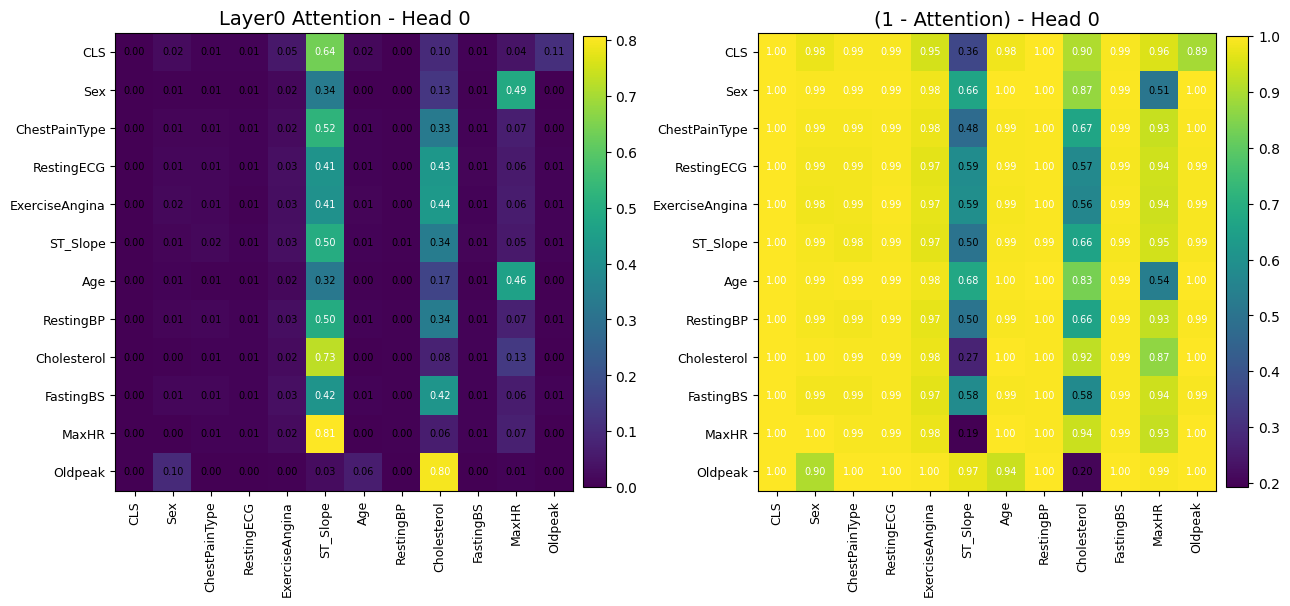

=== Embedding statistics per token (CLS + features) ===
            CLS  | mean=-0.0086 | std=0.4004
            Sex  | mean=0.0594 | std=2.6928
  ChestPainType  | mean=0.0599 | std=2.6938
     RestingECG  | mean=0.0425 | std=2.4687
 ExerciseAngina  | mean=0.0637 | std=2.7589
       ST_Slope  | mean=0.0538 | std=2.6591
            Age  | mean=-0.1135 | std=4.8134
      RestingBP  | mean=0.0675 | std=1.7838
    Cholesterol  | mean=-0.0075 | std=0.4913
      FastingBS  | mean=-0.1536 | std=3.3200
          MaxHR  | mean=0.4036 | std=9.0866
        Oldpeak  | mean=0.1226 | std=3.0981

=== Global embedding statistics ===
global mean: 0.0492
global std : 3.7129


In [45]:
src = sources[0]   # 첫 source
loader = loaders[src]

batch = next(iter(loader))

atts, emb = extract_basis_attention_and_embedding(model, batch)

# feature names 가져오기
var_names = extract_feature_names(batch)
feature_names = ["CLS"] + var_names

# 첫 layer attention 시각화
#plot_attention_heatmap(atts[0], feature_names, "Layer0 Attention")
plot_attention_with_inverse(
    att=atts[0],
    feature_names=feature_names,
    title="Layer0 Attention",
    value_fontsize=7,
    tick_fontsize=9,
    title_fontsize=14,
    figsize_scale=1.3,
)
stats = summarize_embedding_stats(emb, feature_names)



=== Collecting Logits for ALL samples in heart ===


Scanning: 100%|██████████| 29/29 [00:00<00:00, 164.67it/s]


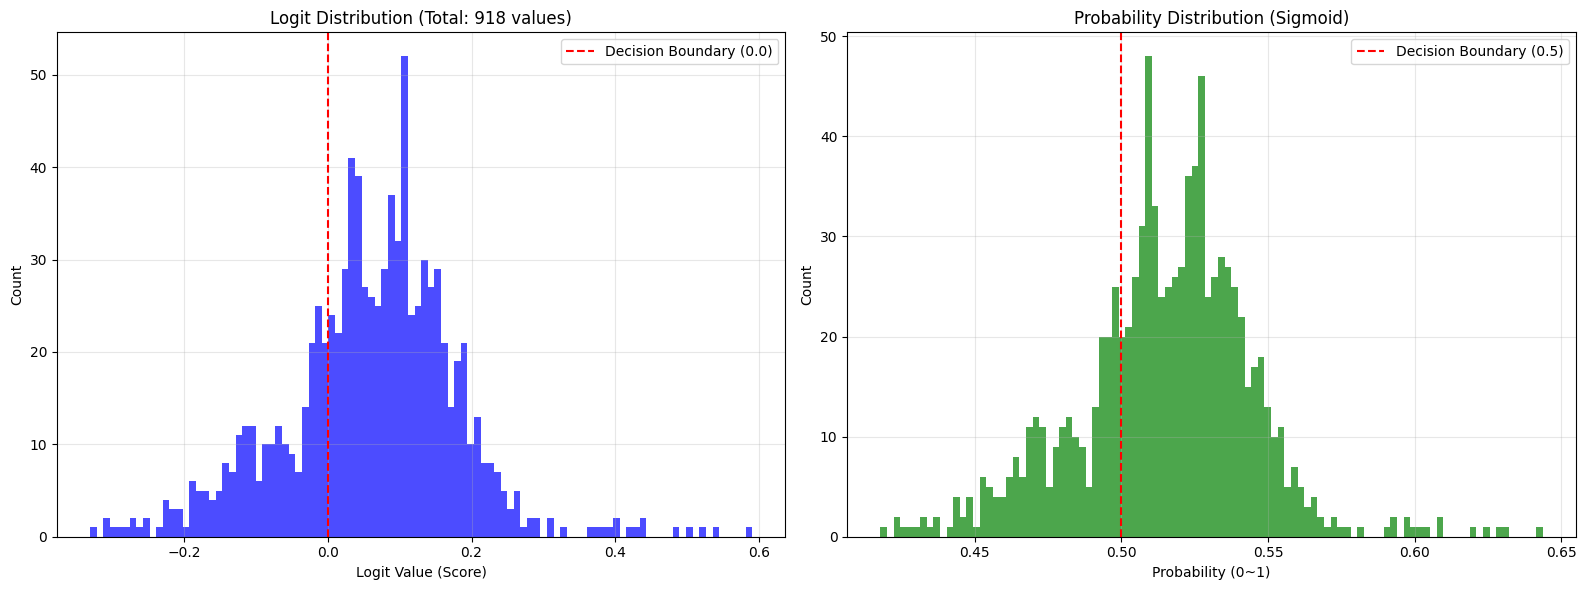


=== Distribution Summary ===
Total Values: 918
[Logit] Min: -0.3314, Max: 0.5910, Mean: 0.0598
[Logit] Std Dev: 0.1204
[Saturation Check] Logit > 5.0 or < -5.0 count: 0 (0.00%)


In [46]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

def plot_logit_distribution(model, loader, src_name):
    model.eval()
    device = model.device
    
    all_logits = []
    all_probs = []
    
    print(f"=== Collecting Logits for ALL samples in {src_name} ===")
    
    # 1. 전체 데이터 순회
    with torch.no_grad():
        for batch in tqdm(loader, desc="Scanning"):
            # 데이터 이동
            batch = {k: (v.to(device) if isinstance(v, torch.Tensor) else v) for k, v in batch.items()}
            
            # 예측 (Logit)
            # model.predict가 있다면 사용, 없으면 직접 forward
            if hasattr(model, 'predict'):
                logits = model.predict(batch)
            else:
                # 만약 predict 함수가 없으면 기존 forward 로직 사용 (간소화)
                # (사용자님 코드 상황에 맞춰 predict가 있다고 가정합니다)
                pass 
            
            # Logit 수집
            # Multi-class인 경우, 예측된 클래스(argmax)의 Logit만 가져올지, 
            # 아니면 전체 Logit의 분포를 볼지 결정해야 함.
            # 여기서는 "모델이 내뱉는 모든 값의 스케일"을 보기 위해 전체를 다 넣습니다.
            all_logits.append(logits.cpu().numpy().flatten())
            all_probs.append(torch.sigmoid(logits).cpu().numpy().flatten())

    # 2. 데이터 병합
    all_logits = np.concatenate(all_logits)
    all_probs = np.concatenate(all_probs)
    
    # 3. 시각화 (좌: Logit, 우: Probability)
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # (1) Logit Histogram
    axes[0].hist(all_logits, bins=100, color='blue', alpha=0.7)
    axes[0].set_title(f"Logit Distribution (Total: {len(all_logits)} values)")
    axes[0].set_xlabel("Logit Value (Score)")
    axes[0].set_ylabel("Count")
    axes[0].grid(True, alpha=0.3)
    # 0.0 기준선 (결정 경계)
    axes[0].axvline(0.0, color='red', linestyle='--', label='Decision Boundary (0.0)')
    axes[0].legend()

    # (2) Probability Histogram
    axes[1].hist(all_probs, bins=100, color='green', alpha=0.7)
    axes[1].set_title("Probability Distribution (Sigmoid)")
    axes[1].set_xlabel("Probability (0~1)")
    axes[1].set_ylabel("Count")
    axes[1].grid(True, alpha=0.3)
    axes[1].axvline(0.5, color='red', linestyle='--', label='Decision Boundary (0.5)')
    axes[1].legend()
    
    plt.tight_layout()
    plt.show()
    
    # 4. 요약 통계 출력
    print("\n=== Distribution Summary ===")
    print(f"Total Values: {len(all_logits)}")
    print(f"[Logit] Min: {all_logits.min():.4f}, Max: {all_logits.max():.4f}, Mean: {all_logits.mean():.4f}")
    print(f"[Logit] Std Dev: {all_logits.std():.4f}")
    
    # Saturation 비율 확인 (절댓값이 5 이상인 경우)
    saturated_count = np.sum(np.abs(all_logits) > 5.0)
    print(f"[Saturation Check] Logit > 5.0 or < -5.0 count: {saturated_count} ({saturated_count/len(all_logits)*100:.2f}%)")

# --- 실행 ---
plot_logit_distribution(model, loaders[sources[0]], sources[0])

In [47]:
# import torch
# import torch.nn as nn
# from torch.optim import Adam
# import numpy as np

# def explain_cls_logit(model, loader, src_name, sample_idx, steps=200, lr=0.1, lambda_l1=0.2, lambda_ent=0.1):
#     model.eval()
#     device = model.device
    
#     # -----------------------------------------------------------
#     # 1. 원본 데이터 로드 (여기서 변수명을 바로 추출)
#     # -----------------------------------------------------------
#     raw_sample = loader.dataset[sample_idx]
    
#     # [수정] 변수명 추출을 raw_sample에서 직접 수행 (Batch wrapper 영향 방지)
#     feature_names = []
    
#     # Categorical Text
#     if 'cat_desc_texts' in raw_sample:
#         # raw_sample['cat_desc_texts']는 리스트 형태 [('Sex',...), ...]
#         for t in raw_sample['cat_desc_texts']:
#             # 튜플이면 첫번째, 아니면 그대로 문자열 변환 후 파싱
#             name = str(t[0] if isinstance(t, tuple) else t).split(",")[0].split("'")[0]
#             feature_names.append(name)
            
#     # Numerical Text
#     if 'num_desc_texts' in raw_sample:
#         for t in raw_sample['num_desc_texts']:
#             name = str(t[0] if isinstance(t, tuple) else t).split(",")[0].split("'")[0]
#             feature_names.append(name)
            
#     # 중복 제거 (순서 유지)
#     seen = set()
#     unique_names = []
#     for n in feature_names:
#         if n not in seen:
#             unique_names.append(n)
#             seen.add(n)
#     feature_names = unique_names

#     # -----------------------------------------------------------
#     # 2. 배치 만들기 (모델 입력용)
#     # -----------------------------------------------------------
#     batch = {}
#     for k, v in raw_sample.items():
#         if isinstance(v, torch.Tensor):
#             batch[k] = v.unsqueeze(0).to(device)
#         else:
#             batch[k] = [v] # 리스트는 그대로 감싸서 전달

#     # -----------------------------------------------------------
#     # 3. 임베딩 준비
#     # -----------------------------------------------------------
#     with torch.no_grad():
#         desc_embeddings, name_embeddings, value_embeddings = [], [], []
        
#         if all(k in batch for k in ['cat_name_embeddings', 'cat_value_embeddings', 'cat_desc_embeddings']):
#             desc_embeddings.append(batch['cat_desc_embeddings'])
#             name_embeddings.append(batch['cat_name_embeddings'])
#             value_embeddings.append(batch['cat_value_embeddings'])
#         if all(k in batch for k in ['num_prompt_embeddings', 'num_desc_embeddings']):
#             desc_embeddings.append(batch['num_desc_embeddings'])
#             name_embeddings.append(batch['num_name_embeddings'])
#             value_embeddings.append(batch['num_prompt_embeddings'])

#         name = torch.cat(name_embeddings, dim=1) 
#         value = torch.cat(value_embeddings, dim=1) 
#         B, N, D = value.shape

#     # -----------------------------------------------------------
#     # 4. 초기 예측(Logit) 확인
#     # -----------------------------------------------------------
#     with torch.no_grad():
#         cls_token = model.basis_cls.expand(B, 1, model.input_dim)
#         x_basis = torch.cat([cls_token, value], dim=1)
        
#         for l in range(model.num_basis_layers):
#             norm_x = model.basis_layer_norms[l](x_basis)
#             basis_outputs, _ = model.basis_layers[l](name, norm_x)
#             x_basis = x_basis + basis_outputs.reshape(x_basis.size(0), x_basis.size(1), model.input_dim)
        
#         local_output = x_basis[:, 0, :]
        
#         if 'src_idx' in batch:
#             idx = int(batch['src_idx'].flatten()[0])
#             logits_origin = model.sheads[idx](local_output)
#         else:
#             logits_origin = model.thead(local_output)
            
#         target_class = torch.argmax(logits_origin, dim=1).item()
#         target_logit_val = logits_origin[0, target_class].item()
        
#         print(f"[{src_name} | ID: {sample_idx}] Prediction: Class {target_class} | Logit: {target_logit_val:.4f}")

#     # -----------------------------------------------------------
#     # 5. 마스크 최적화
#     # -----------------------------------------------------------
#     mask_logits = torch.zeros(1, N, 1, device=device)
#     mask_logits.requires_grad = True
    
#     optimizer = Adam([mask_logits], lr=lr)
#     loss_history = []
    
#     for step in range(steps):
#         optimizer.zero_grad()
#         mask = torch.sigmoid(mask_logits)
        
#         # (A) Masking
#         masked_value = value * mask
        
#         # (B) Forward Replay
#         cls_token = model.basis_cls.expand(B, 1, model.input_dim)
#         x_basis = torch.cat([cls_token, masked_value], dim=1)
        
#         for l in range(model.num_basis_layers):
#             norm_x = model.basis_layer_norms[l](x_basis)
#             basis_outputs, _ = model.basis_layers[l](name, norm_x)
#             x_basis = x_basis + basis_outputs.reshape(x_basis.size(0), x_basis.size(1), model.input_dim)
            
#         local_output = x_basis[:, 0, :]
        
#         if 'src_idx' in batch:
#             idx = int(batch['src_idx'].flatten()[0])
#             logits = model.sheads[idx](local_output)
#         else:
#             logits = model.thead(local_output)
            
#         current_logit = logits[0, target_class]
        
#         loss_logit = -current_logit
#         loss_size = torch.mean(mask)
#         m = mask + 1e-9
#         loss_ent = -m * torch.log(m) - (1-m) * torch.log(1-m)
#         loss_ent = torch.mean(loss_ent)
        
#         loss = loss_logit + lambda_l1 * loss_size + lambda_ent * loss_ent
        
#         loss.backward()
#         optimizer.step()
#         loss_history.append(loss.item())
        
#         if (step+1) % 50 == 0:
#             active_cnt = (mask > 0.5).sum().item()
#             print(f"Step {step+1:03d} | Logit: {current_logit.item():.4f} | Mask Mean: {mask.mean().item():.2f} | Active: {active_cnt}/{N}")

#     feature_importance = torch.sigmoid(mask_logits).detach().cpu().numpy().squeeze()
    
#     # 수정된 feature_names 리턴
#     return feature_importance, feature_names, batch

In [48]:
# import matplotlib.pyplot as plt

# def visualize_importance(importance, feature_names, title="Feature Importance"):
#     # 길이 불일치 예외 처리
#     if len(feature_names) != len(importance):
#         print(f"[Warning] Names({len(feature_names)}) vs Importance({len(importance)}) mismatch.")
#         feature_names = [f"F{i}" for i in range(len(importance))]
    
#     plt.figure(figsize=(10, 5))
#     x_pos = np.arange(len(feature_names))
    
#     # 중요도 0.5 기준으로 색상 구분 (중요: 파랑, 비중요: 회색)
#     colors = ['steelblue' if x > 0.5 else 'lightgray' for x in importance]
    
#     plt.bar(x_pos, importance, align='center', alpha=0.8, color=colors)
#     plt.axhline(0.5, color='red', linestyle='--', linewidth=1, label='Threshold (0.5)')
    
#     plt.xticks(x_pos, feature_names, rotation=90, fontsize=10)
#     plt.ylabel('Importance Score (Mask)')
#     plt.title(title)
#     plt.ylim(0, 1.1)
#     plt.legend()
#     plt.tight_layout()
#     plt.show()

In [49]:
# # 설정
# target_src_name = sources[0]  # 예: 'heart'
# target_loader = loaders[target_src_name]
# target_idx = 0  # <--- 보고 싶은 샘플의 인덱스 (0, 1, 2...)

# # 1. 분석 (인덱스만 넣으면 끝)
# importance, names, batch_used = explain_cls_logit(
#     model, 
#     loader=target_loader, 
#     src_name=target_src_name, 
#     sample_idx=target_idx,  # 여기만 바꾸면 됨
#     steps=200, 
#     lambda_l1=0.2,  # Logit 점수대에 따라 조절 (0.1 ~ 0.5 추천)
#     lambda_ent =0.1
# )

# # 2. GNNExplainer 결과 시각화
# visualize_importance(
#     importance, 
#     names, 
#     title=f"Sample {target_idx} : Key Features for CLS Prediction"
# )

# # 3. Attention Map 비교 (옵션)
# # explain 함수가 리턴해준 batch_used를 그대로 넣으면 됩니다.
# atts, emb = extract_basis_attention_and_embedding(model, batch_used)
# plot_attention_with_inverse(
#     att=atts[0],
#     feature_names=["CLS"] + names,
#     title=f"Sample {target_idx} Attention Map",
#     figsize_scale=1.2
# )

In [50]:
import torch
import torch.nn.functional as F
from torch.optim import Adam
import numpy as np

def explain_cls_logit_debug(model, loader, src_name, sample_idx,
                           steps=200, lr=0.1, lambda_l1=0.2, lambda_ent=0.1):
    model.eval()
    device = next(model.parameters()).device  # model.device 대신 안전한 방식

    raw_sample = loader.dataset[sample_idx]

    # ---- feature_names 추출 (네 코드 그대로) ----
    feature_names = []
    if 'cat_desc_texts' in raw_sample:
        for t in raw_sample['cat_desc_texts']:
            name = str(t[0] if isinstance(t, tuple) else t).split(",")[0].split("'")[0]
            feature_names.append(name)
    if 'num_desc_texts' in raw_sample:
        for t in raw_sample['num_desc_texts']:
            name = str(t[0] if isinstance(t, tuple) else t).split(",")[0].split("'")[0]
            feature_names.append(name)
    seen = set(); unique_names = []
    for n in feature_names:
        if n not in seen:
            unique_names.append(n); seen.add(n)
    feature_names = unique_names

    # ---- batch 만들기 ----
    batch = {}
    for k, v in raw_sample.items():
        if isinstance(v, torch.Tensor):
            batch[k] = v.unsqueeze(0).to(device)
        else:
            batch[k] = [v]

    # ---- name/value 구성 ----
    with torch.no_grad():
        name_embeddings, value_embeddings = [], []
        if all(k in batch for k in ['cat_name_embeddings', 'cat_value_embeddings', 'cat_desc_embeddings']):
            name_embeddings.append(batch['cat_name_embeddings'])
            value_embeddings.append(batch['cat_value_embeddings'])

        # ✅ 여기도 안전하게: num_name_embeddings 포함 체크
        if all(k in batch for k in ['num_name_embeddings', 'num_prompt_embeddings', 'num_desc_embeddings']):
            name_embeddings.append(batch['num_name_embeddings'])
            value_embeddings.append(batch['num_prompt_embeddings'])

        name = torch.cat(name_embeddings, dim=1)
        value = torch.cat(value_embeddings, dim=1)
        B, N, D = value.shape

    # ---- (중요) 원래 예측으로 target y_hat(0/1) 결정 ----
    with torch.no_grad():
        cls_token = model.basis_cls.expand(B, 1, model.input_dim)
        x_basis = torch.cat([cls_token, value], dim=1)
        for l in range(model.num_basis_layers):
            norm_x = model.basis_layer_norms[l](x_basis)
            basis_outputs, _ = model.basis_layers[l](name, norm_x)
            x_basis = x_basis + basis_outputs.reshape(x_basis.size(0), x_basis.size(1), model.input_dim)

        local_output = x_basis[:, 0, :]

        if 'src_idx' in batch:
            idx = int(batch['src_idx'].flatten()[0])
            logits_origin = model.sheads[idx](local_output)   # [1,1]
        else:
            logits_origin = model.thead(local_output)         # [1,1]

        p_origin = torch.sigmoid(logits_origin)[0, 0].item()
        y_hat = 1.0 if p_origin >= 0.5 else 0.0  # ✅ 이게 타깃
        target = torch.tensor([[y_hat]], device=device)       # shape [1,1]
        print(f"[{src_name} | ID: {sample_idx}] y_hat={int(y_hat)} (p={p_origin:.4f})")

    # ---- mask 최적화 ----
    mask_logits = torch.zeros(1, N, 1, device=device, requires_grad=True)
    optimizer = Adam([mask_logits], lr=lr)

    for step in range(steps):
        optimizer.zero_grad()
        mask = torch.sigmoid(mask_logits)
        masked_value = value * mask

        cls_token = model.basis_cls.expand(B, 1, model.input_dim)
        x_basis = torch.cat([cls_token, masked_value], dim=1)
        for l in range(model.num_basis_layers):
            norm_x = model.basis_layer_norms[l](x_basis)
            basis_outputs, _ = model.basis_layers[l](name, norm_x)
            x_basis = x_basis + basis_outputs.reshape(x_basis.size(0), x_basis.size(1), model.input_dim)

        local_output = x_basis[:, 0, :]

        if 'src_idx' in batch:
            idx = int(batch['src_idx'].flatten()[0])
            logits = model.sheads[idx](local_output)  # [1,1]
        else:
            logits = model.thead(local_output)        # [1,1]

        # ✅ 핵심: 학습과 동일하게 BCEWithLogits (logit 기준)
        loss_pred = F.binary_cross_entropy_with_logits(logits, target)

        loss_size = mask.mean()
        m = mask + 1e-9
        loss_ent = -(m * torch.log(m) + (1 - m) * torch.log(1 - m)).mean()

        loss = loss_pred + lambda_l1 * loss_size + lambda_ent * loss_ent
        loss.backward()
        optimizer.step()

    final_mask_logits = mask_logits.detach().cpu().numpy().squeeze()
    final_mask_probs = torch.sigmoid(mask_logits).detach().cpu().numpy().squeeze()
    return final_mask_logits, final_mask_probs, feature_names


[heart | ID: 4] y_hat=1 (p=0.5385)


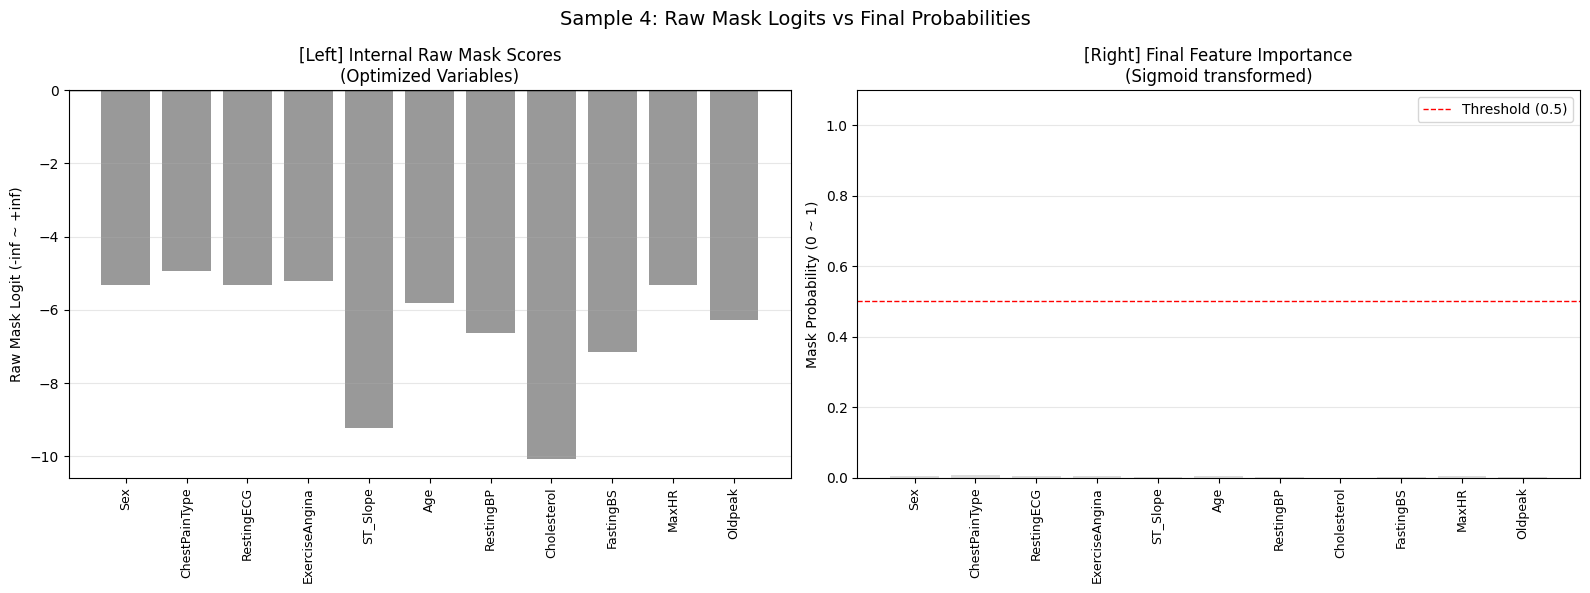

In [51]:
def visualize_logit_vs_prob_side_by_side(raw_logits, probs, feature_names, title="Logit vs Prob Comparison"):
    if len(feature_names) != len(raw_logits):
        feature_names = [f"F{i}" for i in range(len(raw_logits))]
        
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    x_pos = np.arange(len(feature_names))
    
    # --- [왼쪽] Raw Mask Logits (Unbounded) ---
    # 0보다 크면 양수(중요 가능성), 작으면 음수(삭제 가능성)
    colors_logit = ['crimson' if x > 0 else 'gray' for x in raw_logits]
    
    axes[0].bar(x_pos, raw_logits, align='center', alpha=0.8, color=colors_logit)
    axes[0].axhline(0, color='black', linestyle='-', linewidth=1) # 0 기준선
    axes[0].set_xticks(x_pos)
    axes[0].set_xticklabels(feature_names, rotation=90, fontsize=9)
    axes[0].set_ylabel('Raw Mask Logit (-inf ~ +inf)')
    axes[0].set_title(f'[Left] Internal Raw Mask Scores\n(Optimized Variables)')
    axes[0].grid(True, axis='y', alpha=0.3)

    # --- [오른쪽] Mask Probabilities (Sigmoid) ---
    # 0.5보다 크면 중요(파랑), 작으면 비중요(회색)
    colors_prob = ['steelblue' if x > 0.5 else 'lightgray' for x in probs]
    
    axes[1].bar(x_pos, probs, align='center', alpha=0.8, color=colors_prob)
    axes[1].axhline(0.5, color='red', linestyle='--', linewidth=1, label='Threshold (0.5)')
    axes[1].set_xticks(x_pos)
    axes[1].set_xticklabels(feature_names, rotation=90, fontsize=9)
    axes[1].set_ylabel('Mask Probability (0 ~ 1)')
    axes[1].set_title(f'[Right] Final Feature Importance\n(Sigmoid transformed)')
    axes[1].set_ylim(0, 1.1)
    axes[1].legend()
    axes[1].grid(True, axis='y', alpha=0.3)
    
    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()

# --- 실행 ---
target_src_name = sources[0]
target_idx = 4 

# 1. 수정된 함수 실행
raw_logits, probs, names = explain_cls_logit_debug(
    model, 
    loader=loaders[target_src_name], 
    src_name=target_src_name, 
    sample_idx=target_idx, 
    steps=200, 
    lambda_l1=0.2,
    lambda_ent=0.1
)

# 2. 비교 시각화 실행
visualize_logit_vs_prob_side_by_side(
    raw_logits, 
    probs, 
    names, 
    title=f"Sample {target_idx}: Raw Mask Logits vs Final Probabilities"
)

In [52]:
import torch
import torch.nn.functional as F
from torch.optim import Adam

def sample_hard_concrete(log_alpha, beta=2/3, gamma=-0.1, zeta=1.1, training=True):
    """
    log_alpha: [1, N, 1] (learnable)
    returns:
      z_soft in [0,1] (diff)
      z_hard in {0,1} (ST)
    """
    if training:
        u = torch.rand_like(log_alpha)
        s = torch.sigmoid((torch.log(u) - torch.log(1-u) + log_alpha) / beta)
    else:
        s = torch.sigmoid(log_alpha)  # deterministic

    # stretch to (gamma, zeta) then clamp to [0,1]
    z = s * (zeta - gamma) + gamma
    z_soft = torch.clamp(z, 0.0, 1.0)

    # hard (0/1) with straight-through
    z_hard = (z_soft >= 0.5).float()
    z_st = (z_hard - z_soft.detach()) + z_soft
    return z_soft, z_st

def explain_cls_stg_mask(model, loader, src_name, sample_idx,
                         steps=300, lr=0.1,
                         lambda_l0=0.01,  # sparsity strength
                         beta=2/3, gamma=-0.1, zeta=1.1):

    model.eval()
    device = next(model.parameters()).device
    raw_sample = loader.dataset[sample_idx]

    # ---- batch 만들기 (너 코드 그대로 하되 생략) ----
    batch = {}
    for k, v in raw_sample.items():
        if isinstance(v, torch.Tensor):
            batch[k] = v.unsqueeze(0).to(device)
        else:
            batch[k] = [v]

    with torch.no_grad():
        name_embeddings, value_embeddings = [], []
        if all(k in batch for k in ['cat_name_embeddings','cat_value_embeddings','cat_desc_embeddings']):
            name_embeddings.append(batch['cat_name_embeddings'])
            value_embeddings.append(batch['cat_value_embeddings'])
        if all(k in batch for k in ['num_name_embeddings','num_prompt_embeddings','num_desc_embeddings']):
            name_embeddings.append(batch['num_name_embeddings'])
            value_embeddings.append(batch['num_prompt_embeddings'])

        name = torch.cat(name_embeddings, dim=1)
        value = torch.cat(value_embeddings, dim=1)     # [B,N,D]
        B, N, D = value.shape

        # baseline logit 저장 (이게 핵심)
        cls_token = model.basis_cls.expand(B, 1, model.input_dim)
        x_basis = torch.cat([cls_token, value], dim=1)
        for l in range(model.num_basis_layers):
            norm_x = model.basis_layer_norms[l](x_basis)
            basis_outputs, _ = model.basis_layers[l](name, norm_x)
            x_basis = x_basis + basis_outputs.reshape(x_basis.size(0), x_basis.size(1), model.input_dim)
        local_output = x_basis[:, 0, :]

        if 'src_idx' in batch:
            idx = int(batch['src_idx'].flatten()[0])
            logit0 = model.sheads[idx](local_output)
        else:
            logit0 = model.thead(local_output)

        logit0 = logit0.detach()   # <<< baseline 고정
        p0 = torch.sigmoid(logit0)[0,0].item()
        print(f"[{src_name} | ID:{sample_idx}] baseline p={p0:.4f}")

    # learnable gate param
    log_alpha = torch.zeros(1, N, 1, device=device, requires_grad=True)
    opt = Adam([log_alpha], lr=lr)

    for step in range(steps):
        opt.zero_grad()

        z_soft, z_st = sample_hard_concrete(log_alpha, beta=beta, gamma=gamma, zeta=zeta, training=True)
        masked_value = value * z_st  # <<< forward는 hard(0/1) 느낌으로

        # forward replay
        cls_token = model.basis_cls.expand(B, 1, model.input_dim)
        x_basis = torch.cat([cls_token, masked_value], dim=1)
        for l in range(model.num_basis_layers):
            norm_x = model.basis_layer_norms[l](x_basis)
            basis_outputs, _ = model.basis_layers[l](name, norm_x)
            x_basis = x_basis + basis_outputs.reshape(x_basis.size(0), x_basis.size(1), model.input_dim)
        local_output = x_basis[:, 0, :]

        if 'src_idx' in batch:
            idx = int(batch['src_idx'].flatten()[0])
            logits = model.sheads[idx](local_output)
        else:
            logits = model.thead(local_output)

        # ✅ (중요) "원래 출력 유지" loss
        loss_pred = (logits - logit0).pow(2).mean()

        # ✅ sparsity: 기대 활성 개수 줄이기 (L0 근사로 z_soft 평균 사용)
        loss_sparse = z_soft.mean()

        loss = loss_pred + lambda_l0 * loss_sparse
        loss.backward()
        opt.step()

        if (step+1) % 50 == 0:
            hard_on = (z_soft.detach() >= 0.5).sum().item()
            print(f"step {step+1:03d} | loss={loss.item():.4f} | on={hard_on}/{N}")

    final_probs = torch.sigmoid(log_alpha).detach().cpu().numpy().squeeze()  # gate score
    final_hard = (sample_hard_concrete(log_alpha, training=False)[0] >= 0.5).float().detach().cpu().numpy().squeeze()
    return final_probs, final_hard


In [53]:
import numpy as np
import matplotlib.pyplot as plt

def visualize_stg_feature_gates(gate_probs, feature_names=None, gate_hard=None,
                               title="STG / Hard-Concrete Feature Gates",
                               threshold=0.5, topk=None):
    """
    Args:
      gate_probs: (N,) array-like, continuous gate score in [0,1] (e.g., sigmoid(log_alpha))
      feature_names: list[str] length N (optional)
      gate_hard: (N,) array-like, 0/1 hard mask (optional)
      threshold: float, default 0.5
      topk: int or None. If set, show only top-k by gate_probs.

    Behavior:
      - Bar plot sorted by gate_probs (desc)
      - Draw threshold line
      - If gate_hard is provided, annotate ON/OFF
    """
    gate_probs = np.asarray(gate_probs).reshape(-1)
    N = gate_probs.shape[0]

    if feature_names is None or len(feature_names) != N:
        feature_names = [f"F{i}" for i in range(N)]

    order = np.argsort(gate_probs)[::-1]
    if topk is not None:
        order = order[:min(topk, N)]

    probs = gate_probs[order]
    names = [feature_names[i] for i in order]

    if gate_hard is not None:
        gate_hard = np.asarray(gate_hard).reshape(-1)
        hard = gate_hard[order]
    else:
        hard = None

    # --- plot ---
    plt.figure(figsize=(max(10, 0.6 * len(order)), 5))
    x = np.arange(len(order))
    plt.bar(x, probs)
    plt.axhline(threshold, linestyle="--", linewidth=1)
    plt.xticks(x, names, rotation=45, ha="right")
    plt.ylim(0.0, 1.05)
    plt.ylabel("Gate probability (0~1)")
    plt.title(title)
    plt.grid(True, axis="y", linestyle="--", alpha=0.3)

    # annotate hard on/off
    if hard is not None:
        for xi, pi, hi in zip(x, probs, hard):
            txt = "ON" if hi >= 0.5 else "OFF"
            plt.text(xi, min(1.02, pi + 0.03), txt, ha="center", va="bottom", fontsize=9)

    plt.tight_layout()
    plt.show()


def summarize_top_features(gate_probs, feature_names=None, gate_hard=None, topk=10, threshold=0.5):
    """
    Prints a concise ranked list with gate_probs and optional hard mask.
    """
    gate_probs = np.asarray(gate_probs).reshape(-1)
    N = gate_probs.shape[0]
    if feature_names is None or len(feature_names) != N:
        feature_names = [f"F{i}" for i in range(N)]

    order = np.argsort(gate_probs)[::-1]
    order = order[:min(topk, N)]

    print(f"Top-{len(order)} features by gate probability:")
    for rank, i in enumerate(order, 1):
        p = float(gate_probs[i])
        name = feature_names[i]
        if gate_hard is not None:
            h = int(np.asarray(gate_hard).reshape(-1)[i] >= 0.5)
            status = "ON" if (p >= threshold) else "OFF"
            print(f"{rank:02d}. {name:>20} | p={p:.4f} | hard={h} | {status}")
        else:
            status = "ON" if (p >= threshold) else "OFF"
            print(f"{rank:02d}. {name:>20} | p={p:.4f} | {status}")


def plot_gate_histogram(gate_probs, title="Gate probability histogram", bins=20):
    """
    Quick sanity-check: are gates collapsing to 0 or 1?
    """
    gate_probs = np.asarray(gate_probs).reshape(-1)
    plt.figure(figsize=(7, 4))
    plt.hist(gate_probs, bins=bins)
    plt.xlabel("Gate probability")
    plt.ylabel("Count")
    plt.title(title)
    plt.grid(True, axis="y", linestyle="--", alpha=0.3)
    plt.tight_layout()
    plt.show()


[heart | ID:0] baseline p=0.5379
step 050 | loss=0.0120 | on=6/11
step 100 | loss=0.0144 | on=8/11
step 150 | loss=0.0071 | on=8/11
step 200 | loss=0.0084 | on=9/11
step 250 | loss=0.0274 | on=7/11
step 300 | loss=0.0068 | on=4/11


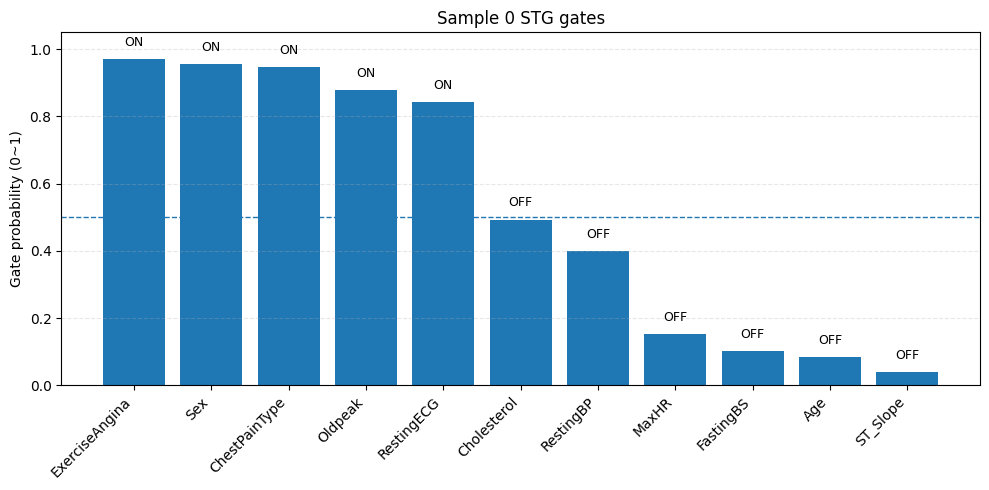

Top-11 features by gate probability:
01.       ExerciseAngina | p=0.9707 | hard=1 | ON
02.                  Sex | p=0.9565 | hard=1 | ON
03.        ChestPainType | p=0.9462 | hard=1 | ON
04.              Oldpeak | p=0.8785 | hard=1 | ON
05.           RestingECG | p=0.8416 | hard=1 | ON
06.          Cholesterol | p=0.4931 | hard=0 | OFF
07.            RestingBP | p=0.3999 | hard=0 | OFF
08.                MaxHR | p=0.1538 | hard=0 | OFF
09.            FastingBS | p=0.1010 | hard=0 | OFF
10.                  Age | p=0.0836 | hard=0 | OFF
11.             ST_Slope | p=0.0394 | hard=0 | OFF


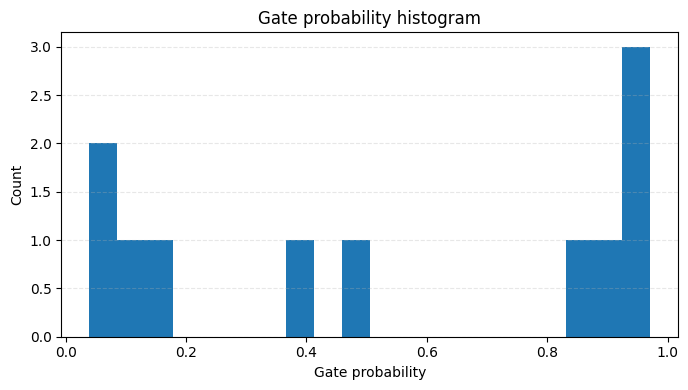

In [54]:
gate_probs, gate_hard = explain_cls_stg_mask(model, loader, "heart", sample_idx=0, steps=300, lr=0.1, lambda_l0=0.01)

visualize_stg_feature_gates(
    gate_probs,
    feature_names=names,      # 너가 추출한 feature_names
    gate_hard=gate_hard,
    title="Sample 0 STG gates",
    topk=20
)

summarize_top_features(gate_probs, names, gate_hard=gate_hard, topk=15)
plot_gate_histogram(gate_probs)


In [55]:
import torch
import torch.nn.functional as F
from torch.optim import Adam
import numpy as np

@torch.no_grad()
def _forward_with_override(model, name, value, batch, override_adj=None):
    """
    override_adj: [B, N+1, N+1] or None
    returns logits: [B,1] (binary)
    """
    B, N, D = value.shape

    # override 백업 & 세팅
    saved = []
    for l in range(model.num_basis_layers):
        layer = model.basis_layers[l]
        saved.append(getattr(layer, "override_adj", None))
        layer.override_adj = override_adj

    cls_token = model.basis_cls.expand(B, 1, model.input_dim)
    x_basis = torch.cat([cls_token, value], dim=1)

    for l in range(model.num_basis_layers):
        norm_x = model.basis_layer_norms[l](x_basis)
        basis_outputs, _ = model.basis_layers[l](name, norm_x)
        x_basis = x_basis + basis_outputs.reshape(B, x_basis.size(1), model.input_dim)

    local_output = x_basis[:, 0, :]

    if 'src_idx' in batch:
        idx = int(batch['src_idx'].flatten()[0])
        logits = model.sheads[idx](local_output)
    else:
        logits = model.thead(local_output)

    # override 복구
    for l in range(model.num_basis_layers):
        model.basis_layers[l].override_adj = saved[l]

    return logits


def explain_cls_adj_gnnexplainer_like(
    model, loader, src_name, sample_idx,
    steps=300, lr=0.1, lambda_l1=0.05, lambda_ent=0.1,
    temp=1.0, no_self_loop=False
):
    """
    GNNExplainer 스타일로 '노드 게이트'를 학습해서
    (1) 중요한 변수(게이트↑) / (2) 덜 중요한 변수(게이트↓)를 뽑음.
    Var->CLS는 항상 0으로 고정.
    """
    model.eval()
    device = next(model.parameters()).device

    raw_sample = loader.dataset[sample_idx]

    # ---- feature_names 추출 (네 로직 유지) ----
    feature_names = []
    if 'cat_desc_texts' in raw_sample:
        for t in raw_sample['cat_desc_texts']:
            name = str(t[0] if isinstance(t, tuple) else t).split(",")[0].split("'")[0]
            feature_names.append(name)
    if 'num_desc_texts' in raw_sample:
        for t in raw_sample['num_desc_texts']:
            name = str(t[0] if isinstance(t, tuple) else t).split(",")[0].split("'")[0]
            feature_names.append(name)
    seen = set(); unique_names = []
    for n in feature_names:
        if n not in seen:
            unique_names.append(n); seen.add(n)
    feature_names = unique_names

    # ---- batch 만들기 ----
    batch = {}
    for k, v in raw_sample.items():
        if isinstance(v, torch.Tensor):
            batch[k] = v.unsqueeze(0).to(device)
        else:
            batch[k] = [v]

    # ---- name/value 구성 ----
    with torch.no_grad():
        name_embeddings, value_embeddings = [], []
        if all(k in batch for k in ['cat_name_embeddings', 'cat_value_embeddings', 'cat_desc_embeddings']):
            name_embeddings.append(batch['cat_name_embeddings'])
            value_embeddings.append(batch['cat_value_embeddings'])
        if all(k in batch for k in ['num_name_embeddings', 'num_prompt_embeddings', 'num_desc_embeddings']):
            name_embeddings.append(batch['num_name_embeddings'])
            value_embeddings.append(batch['num_prompt_embeddings'])

        name = torch.cat(name_embeddings, dim=1)
        value = torch.cat(value_embeddings, dim=1)
        B, N, D = value.shape  # N = 변수 개수 (CLS 제외)

    # ---- 원본 예측으로 target y_hat 결정 (override 없이) ----
    with torch.no_grad():
        logits0 = _forward_with_override(model, name, value, batch, override_adj=None)
        p0 = torch.sigmoid(logits0)[0, 0].item()
        y_hat = 1.0 if p0 >= 0.5 else 0.0
        target = torch.tensor([[y_hat]], device=device)
        print(f"[{src_name} | ID: {sample_idx}] y_hat={int(y_hat)} (p={p0:.4f})")

    # ---- 학습 파라미터: 변수 게이트 ----
    node_logits = torch.zeros(1, N, device=device, requires_grad=True)
    # 보통은 "다 켜놓고 prune"이 안정적
    torch.nn.init.constant_(node_logits, 1.0)

    opt = Adam([node_logits], lr=lr)

    # Var->CLS off를 강제로 고정하는 상수 마스크 (in-place 방지)
    fixed = torch.ones(1, N+1, N+1, device=device)
    fixed[:, 1:, 0] = 0.0  # Var->CLS = 0
    fixed = fixed.expand(B, -1, -1)

    final_adj = None
    for step in range(steps):
        opt.zero_grad()

        node_prob = torch.sigmoid(node_logits / temp)  # [1,N] in (0,1)

        # full_node_mask: [1, N+1] (CLS는 항상 1)
        cls_mask = torch.ones(1, 1, device=device)
        full_node_mask = torch.cat([cls_mask, node_prob], dim=1)  # [1, N+1]

        # adjacency = outer product (노드 꺼지면 그 노드에 닿는 엣지 전부 약화)
        adj = full_node_mask.t() @ full_node_mask  # [N+1, N+1]
        adj = adj.unsqueeze(0).expand(B, -1, -1)    # [B, N+1, N+1]

        # self-loop 처리 (override에서는 네 var_adj를 안 타니까 여기서 맞춰줘야 함)
        if no_self_loop:
            eye = torch.eye(N+1, device=device).unsqueeze(0).expand(B, -1, -1)
            adj = adj * (1.0 - eye)
        else:
            # diag는 1로 두고 싶으면 유지(기본 adj가 그런지에 맞춰)
            pass

        # Var->CLS off 고정
        final_adj = adj * fixed

        # forward (override 주입)
        logits = _forward_with_override(model, name, value, batch, override_adj=final_adj)

        # loss: 원래 예측 유지 + sparsity + entropy
        loss_pred = F.binary_cross_entropy_with_logits(logits, target)
        loss_size = node_prob.mean()
        m = node_prob.clamp(1e-9, 1 - 1e-9)
        loss_ent = -(m * torch.log(m) + (1 - m) * torch.log(1 - m)).mean()

        loss = loss_pred + lambda_l1 * loss_size + lambda_ent * loss_ent
        loss.backward()
        opt.step()

        if (step + 1) % 50 == 0:
            active = (node_prob >= 0.5).sum().item()
            with torch.no_grad():
                p = torch.sigmoid(logits)[0, 0].item()
            print(f"Step {step+1:03d} | loss={loss.item():.4f} | p={p:.4f} | active={active}/{N}")

    gate_prob = torch.sigmoid(node_logits).detach().cpu().numpy().squeeze()  # [N]
    return gate_prob, final_adj, feature_names


In [63]:
import torch
import torch.nn.functional as F
from torch.optim import Adam
import numpy as np

def _forward_with_override(model, name_embeddings, value_embeddings, batch, override_adj=None):
    """
    override_adj: [B, N+1, N+1] or None
    returns logits: [B,1] (binary)
    """
    B, N, D = value_embeddings.shape

    # override 백업 & 세팅
    saved = []
    for l in range(model.num_basis_layers):
        layer = model.basis_layers[l]
        saved.append(getattr(layer, "override_adj", None))
        layer.override_adj = override_adj

    try:
        cls_token = model.basis_cls.expand(B, 1, model.input_dim)
        x_basis = torch.cat([cls_token, value_embeddings], dim=1)

        for l in range(model.num_basis_layers):
            norm_x = model.basis_layer_norms[l](x_basis)
            basis_outputs, _ = model.basis_layers[l](name_embeddings, norm_x)
            x_basis = x_basis + basis_outputs.reshape(B, x_basis.size(1), model.input_dim)

        local_output = x_basis[:, 0, :]

        if 'src_idx' in batch:
            idx = int(batch['src_idx'].flatten()[0])
            logits = model.sheads[idx](local_output)
        else:
            logits = model.thead(local_output)

    finally:
        # override 복구 (무조건)
        for l in range(model.num_basis_layers):
            model.basis_layers[l].override_adj = saved[l]

    return logits


def explain_cls_adj_gnnexplainer_like(
    model, loader, src_name, sample_idx,
    steps=300, lr=0.1, lambda_l1=0.05, lambda_ent=0.1,
    temp=1.0, no_self_loop=False
):
    """
    GNNExplainer 스타일: adjacency를 post-hoc으로 학습.
    - Var->CLS는 항상 0 고정
    - forward에서는 new_adj가 '진짜 0/1'이 되도록 STE 적용 (너희 모델이 new_adj==0만 마스킹하므로)
    """
    model.eval()
    device = next(model.parameters()).device

    raw_sample = loader.dataset[sample_idx]

    # ---- feature_names 추출 (네 로직 유지) ----
    feature_names = []
    if 'cat_desc_texts' in raw_sample:
        for t in raw_sample['cat_desc_texts']:
            name = str(t[0] if isinstance(t, tuple) else t).split(",")[0].split("'")[0]
            feature_names.append(name)
    if 'num_desc_texts' in raw_sample:
        for t in raw_sample['num_desc_texts']:
            name = str(t[0] if isinstance(t, tuple) else t).split(",")[0].split("'")[0]
            feature_names.append(name)
    seen = set(); unique_names = []
    for n in feature_names:
        if n not in seen:
            unique_names.append(n); seen.add(n)
    feature_names = unique_names

    # ---- batch 만들기 ----
    batch = {}
    for k, v in raw_sample.items():
        if isinstance(v, torch.Tensor):
            batch[k] = v.unsqueeze(0).to(device)
        else:
            batch[k] = [v]

    # ---- name/value 구성 ----
    with torch.no_grad():
        name_list, value_list = [], []
        if all(k in batch for k in ['cat_name_embeddings', 'cat_value_embeddings', 'cat_desc_embeddings']):
            name_list.append(batch['cat_name_embeddings'])
            value_list.append(batch['cat_value_embeddings'])
        if all(k in batch for k in ['num_name_embeddings', 'num_prompt_embeddings', 'num_desc_embeddings']):
            name_list.append(batch['num_name_embeddings'])
            value_list.append(batch['num_prompt_embeddings'])

        name_embeddings = torch.cat(name_list, dim=1)
        value_embeddings = torch.cat(value_list, dim=1)
        B, N, D = value_embeddings.shape  # N = 변수 개수 (CLS 제외)

    # ---- 원본 예측으로 target y_hat 결정 (override 없이) ----
    with torch.no_grad():
        logits0 = _forward_with_override(model, name_embeddings, value_embeddings, batch, override_adj=None)
        p0 = torch.sigmoid(logits0)[0, 0].item()
        y_hat = 1.0 if p0 >= 0.5 else 0.0
        target = torch.tensor([[y_hat]], device=device)
        print(f"[{src_name} | ID: {sample_idx}] y_hat={int(y_hat)} (p={p0:.4f})")

    # ---- 학습 파라미터: 노드 게이트 ----
    node_logits = torch.zeros(1, N, device=device, requires_grad=True)
    torch.nn.init.constant_(node_logits, 1.0)  # 다 켜고 prune

    opt = Adam([node_logits], lr=lr)

    # Var->CLS off 고정 (항상 0)
    fixed = torch.ones(1, N+1, N+1, device=device)
    fixed[:, 1:, 0] = 0.0
    fixed = fixed.expand(B, -1, -1)

    final_adj = None
    for step in range(steps):
        opt.zero_grad()

        # soft prob
        node_prob = torch.sigmoid(node_logits / temp)  # [1,N]

        # ✅ STE로 forward에서는 hard 0/1, backward는 node_prob로
        node_hard = (node_prob >= 0.5).float()
        node_mask = (node_hard - node_prob.detach()) + node_prob  # 값은 hard(0/1) 그대로

        cls_mask = torch.ones(1, 1, device=device)
        full_mask = torch.cat([cls_mask, node_mask], dim=1)  # [1, N+1]

        # outer product -> [N+1, N+1] 값은 "정확히 0/1"
        adj = full_mask.t() @ full_mask
        adj = adj.unsqueeze(0).expand(B, -1, -1)

        if no_self_loop:
            eye = torch.eye(N+1, device=device).unsqueeze(0).expand(B, -1, -1)
            adj = adj * (1.0 - eye)  # diag를 0으로 (여기도 값은 0/1)

        # Var->CLS off 고정 (0 유지)
        final_adj = adj * fixed

        # forward with override
        logits = _forward_with_override(model, name_embeddings, value_embeddings, batch, override_adj=final_adj)

        # loss
        loss_pred = F.binary_cross_entropy_with_logits(logits, target)

        # sparsity/entropy는 soft로 걸어야 의미있음
        loss_size = node_prob.mean()
        m = node_prob.clamp(1e-9, 1 - 1e-9)
        loss_ent = -(m * torch.log(m) + (1 - m) * torch.log(1 - m)).mean()

        loss = loss_pred + lambda_l1 * loss_size + lambda_ent * loss_ent
        loss.backward()
        opt.step()

        if (step + 1) % 50 == 0:
            active = (node_hard >= 0.5).sum().item()
            with torch.no_grad():
                p = torch.sigmoid(logits)[0, 0].item()
            print(f"Step {step+1:03d} | loss={loss.item():.4f} | p={p:.4f} | active={active}/{N}")

    gate_prob = torch.sigmoid(node_logits).detach().cpu().numpy().squeeze()  # [N]
    return gate_prob, final_adj, feature_names


In [64]:
@torch.no_grad()
def rank_drop_by_ablation(model, loader, src_name, sample_idx, feature_names, no_self_loop=False):
    """
    각 변수를 하나씩 완전히 끊었을 때(prob 변화량) 기반으로
    drop해도 안전한(변화 작은) 변수부터 정렬.
    Var->CLS는 계속 0 유지.
    """
    model.eval()
    device = next(model.parameters()).device

    raw_sample = loader.dataset[sample_idx]
    batch = {}
    for k, v in raw_sample.items():
        if isinstance(v, torch.Tensor):
            batch[k] = v.unsqueeze(0).to(device)
        else:
            batch[k] = [v]

    with torch.no_grad():
        name_embeddings, value_embeddings = [], []
        if all(k in batch for k in ['cat_name_embeddings', 'cat_value_embeddings', 'cat_desc_embeddings']):
            name_embeddings.append(batch['cat_name_embeddings'])
            value_embeddings.append(batch['cat_value_embeddings'])
        if all(k in batch for k in ['num_name_embeddings', 'num_prompt_embeddings', 'num_desc_embeddings']):
            name_embeddings.append(batch['num_name_embeddings'])
            value_embeddings.append(batch['num_prompt_embeddings'])

        name = torch.cat(name_embeddings, dim=1)
        value = torch.cat(value_embeddings, dim=1)
        B, N, D = value.shape

    # base prob (override=None = 원래 그래프)
    logits0 = _forward_with_override(model, name, value, batch, override_adj=None)
    p0 = torch.sigmoid(logits0)[0, 0].item()

    # 고정 마스크 (Var->CLS off)
    fixed = torch.ones(1, N+1, N+1, device=device)
    fixed[:, 1:, 0] = 0.0
    fixed = fixed.expand(B, -1, -1)

    results = []
    for i in range(N):
        # node mask: 모두 1인데 i만 0
        node = torch.ones(1, N, device=device)
        node[0, i] = 0.0

        full = torch.cat([torch.ones(1, 1, device=device), node], dim=1)  # [1,N+1]
        adj = full.t() @ full
        adj = adj.unsqueeze(0).expand(B, -1, -1)

        if no_self_loop:
            eye = torch.eye(N+1, device=device).unsqueeze(0).expand(B, -1, -1)
            adj = adj * (1.0 - eye)

        adj = adj * fixed

        logits = _forward_with_override(model, name, value, batch, override_adj=adj)
        p = torch.sigmoid(logits)[0, 0].item()

        results.append((feature_names[i], p, abs(p - p0)))

    # 변화 작은 순(=drop해도 안전)
    results.sort(key=lambda x: x[2])
    return p0, results


In [65]:
import matplotlib.pyplot as plt
import numpy as np

def plot_gate_probs(gate_prob, feature_names, thr=0.5, title="Explainer gate probabilities"):
    idx = np.argsort(gate_prob)[::-1]
    names = [feature_names[i] for i in idx]
    vals = gate_prob[idx]

    plt.figure(figsize=(12, 4))
    plt.bar(range(len(vals)), vals)
    plt.axhline(thr, linestyle="--", linewidth=1.5, label=f"threshold={thr}")
    plt.xticks(range(len(vals)), names, rotation=45, ha="right")
    plt.ylim(0, 1.05)
    plt.title(title)
    plt.ylabel("gate prob (0~1)")
    plt.grid(axis="y", alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_ablation(results, topk=15, title="Drop-safety (|Δp| small = safe to drop)"):
    # results: [(name, p, abs_delta), ...] already sorted by abs_delta asc
    show = results[:topk]
    names = [x[0] for x in show]
    deltas = [x[2] for x in show]

    plt.figure(figsize=(12, 4))
    plt.bar(range(len(deltas)), deltas)
    plt.xticks(range(len(deltas)), names, rotation=45, ha="right")
    plt.title(title)
    plt.ylabel("|Δp|")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()


[heart | ID: 0] y_hat=1 (p=0.5379)
Step 050 | loss=0.6735 | p=0.5379 | active=11/11
Step 100 | loss=0.6712 | p=0.5379 | active=11/11
Step 150 | loss=0.6707 | p=0.5379 | active=11/11
Step 200 | loss=0.6705 | p=0.5379 | active=11/11
Step 250 | loss=0.6704 | p=0.5379 | active=11/11
Step 300 | loss=0.6703 | p=0.5379 | active=11/11


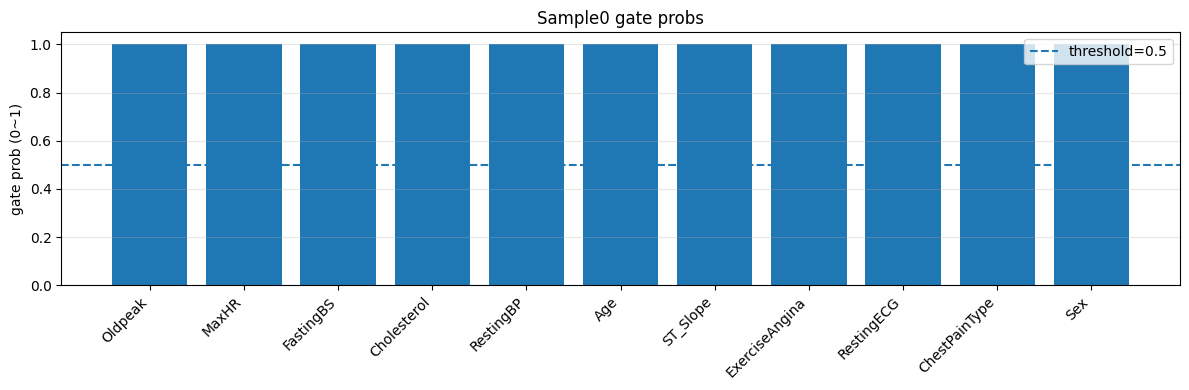

base p = 0.5379235148429871
Top safe-to-drop (small |Δp|):
                 Sex  p=0.5379  |Δp|=0.0000
       ChestPainType  p=0.5379  |Δp|=0.0000
          RestingECG  p=0.5379  |Δp|=0.0000
      ExerciseAngina  p=0.5379  |Δp|=0.0000
            ST_Slope  p=0.5379  |Δp|=0.0000
                 Age  p=0.5379  |Δp|=0.0000
           RestingBP  p=0.5379  |Δp|=0.0000
         Cholesterol  p=0.5379  |Δp|=0.0000
           FastingBS  p=0.5379  |Δp|=0.0000
               MaxHR  p=0.5379  |Δp|=0.0000


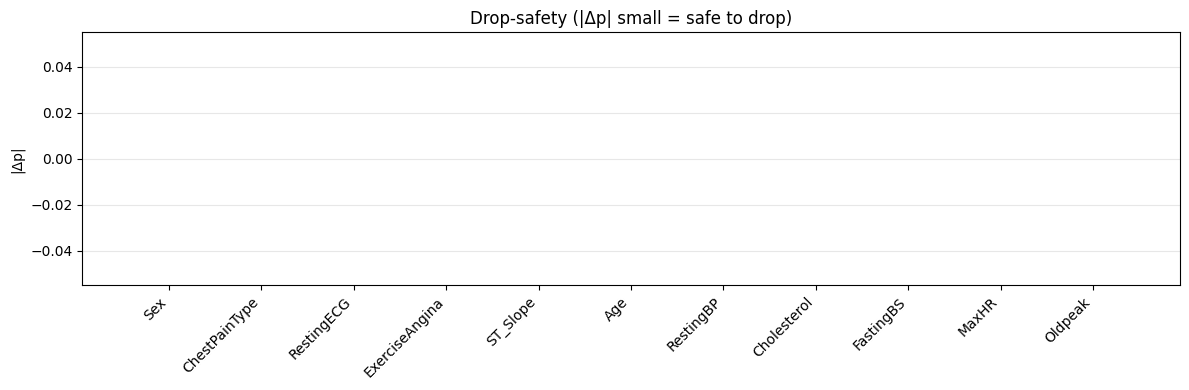

In [66]:
gate_prob, final_adj, names = explain_cls_adj_gnnexplainer_like(
    model, loader, "heart", sample_idx=0,
    steps=300, lr=0.1, lambda_l1=0.05, lambda_ent=0.1,
    temp=1.0,
    no_self_loop=getattr(model.basis_layers[0].args, "no_self_loop", False)
)

plot_gate_probs(gate_prob, names, thr=0.5, title="Sample0 gate probs")

p0, abls = rank_drop_by_ablation(model, loader, "heart", 0, names,
                                 no_self_loop=getattr(model.basis_layers[0].args, "no_self_loop", False))
print("base p =", p0)
print("Top safe-to-drop (small |Δp|):")
for n, p, dp in abls[:10]:
    print(f"{n:>20}  p={p:.4f}  |Δp|={dp:.4f}")

plot_ablation(abls, topk=15)


In [60]:
# 임의로 CLS->var를 전부 끊어버리는 override



## Do Not Touch

In [61]:
import torch
import torch.nn as nn
from torch.optim import Adam
import numpy as np

def explain_cls_prob(model, loader, src_name, sample_idx, steps=200, lr=0.1, lambda_l1=0.2, lambda_ent=0.1):
    model.eval()
    device = model.device
    
    # 1. 데이터 로드 및 변수명 추출 (기존과 동일)
    raw_sample = loader.dataset[sample_idx]
    feature_names = []
    if 'cat_desc_texts' in raw_sample:
        for t in raw_sample['cat_desc_texts']:
            name = str(t[0] if isinstance(t, tuple) else t).split(",")[0].split("'")[0]
            feature_names.append(name)
    if 'num_desc_texts' in raw_sample:
        for t in raw_sample['num_desc_texts']:
            name = str(t[0] if isinstance(t, tuple) else t).split(",")[0].split("'")[0]
            feature_names.append(name)
    seen = set(); unique_names = []
    for n in feature_names:
        if n not in seen: unique_names.append(n); seen.add(n)
    feature_names = unique_names

    # 2. 배치 생성 (기존과 동일)
    batch = {}
    for k, v in raw_sample.items():
        if isinstance(v, torch.Tensor):
            batch[k] = v.unsqueeze(0).to(device)
        else:
            batch[k] = [v]

    # 3. 임베딩 준비 (기존과 동일)
    with torch.no_grad():
        desc_embeddings, name_embeddings, value_embeddings = [], [], []
        if all(k in batch for k in ['cat_name_embeddings', 'cat_value_embeddings', 'cat_desc_embeddings']):
            desc_embeddings.append(batch['cat_desc_embeddings'])
            name_embeddings.append(batch['cat_name_embeddings'])
            value_embeddings.append(batch['cat_value_embeddings'])
        if all(k in batch for k in ['num_prompt_embeddings', 'num_desc_embeddings']):
            desc_embeddings.append(batch['num_desc_embeddings'])
            name_embeddings.append(batch['num_name_embeddings'])
            value_embeddings.append(batch['num_prompt_embeddings'])

        name = torch.cat(name_embeddings, dim=1) 
        value = torch.cat(value_embeddings, dim=1) 
        B, N, D = value.shape

    # 4. 초기 예측 확인 (수정: Logit -> Prob)
    with torch.no_grad():
        # ... (Forward 과정은 동일) ...
        cls_token = model.basis_cls.expand(B, 1, model.input_dim)
        x_basis = torch.cat([cls_token, value], dim=1)
        for l in range(model.num_basis_layers):
            norm_x = model.basis_layer_norms[l](x_basis)
            basis_outputs, _ = model.basis_layers[l](name, norm_x)
            x_basis = x_basis + basis_outputs.reshape(x_basis.size(0), x_basis.size(1), model.input_dim)
        local_output = x_basis[:, 0, :]
        
        if 'src_idx' in batch:
            idx = int(batch['src_idx'].flatten()[0])
            logits_origin = model.sheads[idx](local_output)
        else:
            logits_origin = model.thead(local_output)
            
        # [중요] 초기 Target Class 설정
        if logits_origin.size(1) == 1: # Binary (Output 1개)
            prob_origin = torch.sigmoid(logits_origin)
            target_class = 1 if prob_origin.item() > 0.5 else 0
        else: # Multi-class (Output 2개 이상)
            prob_origin = torch.softmax(logits_origin, dim=1)
            target_class = torch.argmax(prob_origin, dim=1).item()
            
        print(f"[{src_name} | ID: {sample_idx}] Target Class: {target_class}")

    # 5. 마스크 최적화
    mask_logits = torch.zeros(1, N, 1, device=device)
    mask_logits.requires_grad = True
    optimizer = Adam([mask_logits], lr=lr)
    
    for step in range(steps):
        optimizer.zero_grad()
        mask = torch.sigmoid(mask_logits)
        
        # (A) Masking
        masked_value = value * mask
        
        # (B) Forward Replay
        cls_token = model.basis_cls.expand(B, 1, model.input_dim)
        x_basis = torch.cat([cls_token, masked_value], dim=1)
        
        for l in range(model.num_basis_layers):
            norm_x = model.basis_layer_norms[l](x_basis)
            basis_outputs, _ = model.basis_layers[l](name, norm_x)
            x_basis = x_basis + basis_outputs.reshape(x_basis.size(0), x_basis.size(1), model.input_dim)
            
        local_output = x_basis[:, 0, :]
        if 'src_idx' in batch:
            idx = int(batch['src_idx'].flatten()[0])
            logits = model.sheads[idx](local_output)
        else:
            logits = model.thead(local_output)
            
        # ------------------------------------------------------------------
        # [핵심 수정] Logit 대신 Probability 사용
        # ------------------------------------------------------------------
        if logits.size(1) == 1:
            # Binary Case: Output이 1개일 때
            current_prob = torch.sigmoid(logits)[0, 0]
            if target_class == 1:
                target_prob = current_prob      # Class 1이면 그대로 P
            else:
                target_prob = 1.0 - current_prob # Class 0이면 (1-P)
        else:
            # Multi-class Case
            current_probs = torch.softmax(logits, dim=1)
            target_prob = current_probs[0, target_class]

        # Loss 1: Prediction Loss (NLL Loss 사용)
        # -log(P)를 최소화 = P를 최대화 (기울기가 훨씬 안정적임)
        loss_pred = -torch.log(target_prob + 1e-9)
        
        # Loss 2 & 3: Size & Entropy
        loss_size = torch.mean(mask)
        m = mask + 1e-9
        loss_ent = -torch.mean(m * torch.log(m) + (1-m) * torch.log(1-m))
        
        loss = loss_pred + lambda_l1 * loss_size + lambda_ent * loss_ent
        
        loss.backward()
        optimizer.step()
        
    feature_importance = torch.sigmoid(mask_logits).detach().cpu().numpy().squeeze()
    return feature_importance, feature_names, batch

In [62]:
# -------------------------------------------------------------
# 1. 설정 및 실행 (함수 이름을 explain_cls_prob 로 변경!)
# -------------------------------------------------------------
target_src_name = sources[0]
target_loader = loaders[target_src_name]
target_idx = 900  # 아까 그 샘플

# explain_cls_prob 함수 호출 (lambda_ent 추가됨)
importance_prob, names_prob, batch_used = explain_cls_prob(
    model, 
    loader=target_loader, 
    src_name=target_src_name, 
    sample_idx=target_idx, 
    steps=300, 
    lr=0.05,
    lambda_l1=0.05,    # 마스크 크기 규제 (Sparsity)
    lambda_ent=0.1    # [New] 엔트로피 규제 (0 or 1로 확실히 밀어주기)
)

# -------------------------------------------------------------
# 2. 결과 시각화 (이건 그대로 쓰면 됨)
# -------------------------------------------------------------
visualize_importance(
    importance_prob, 
    names_prob, 
    title=f"Sample {target_idx} (Prob Based) Importance"
)

# -------------------------------------------------------------
# 3. Attention Map 비교 (이것도 그대로 쓰면 됨)
# -------------------------------------------------------------
# explain 함수가 리턴해준 batch_used를 그대로 넣으면 됩니다.
atts, emb = extract_basis_attention_and_embedding(model, batch_used)

plot_attention_with_inverse(
    att=atts[0],
    feature_names=["CLS"] + names_prob, # 변수명도 리턴받은거 그대로 사용
    title=f"Sample {target_idx} Attention Map",
    figsize_scale=1.2
)

[heart | ID: 900] Target Class: 0


NameError: name 'visualize_importance' is not defined

[heart | ID: 900] Target Class: 0


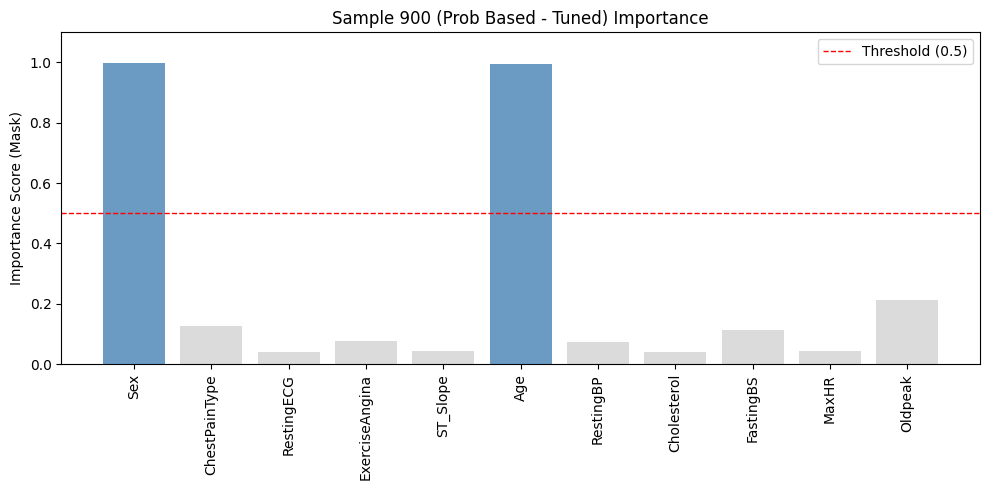

In [ ]:
# -------------------------------------------------------------
# [솔루션] Prob 방식의 Hyperparameter 재조정
# -------------------------------------------------------------
target_src_name = sources[0]
target_loader = loaders[target_src_name]
target_idx = 900  # Sample 0 (Logit에서 ChestPainType 나왔던 그 샘플)

# 핵심 변경: lambda_l1을 0.2 -> 0.05 로 대폭 낮춤!
# 이유: Prob의 기울기가 Logit보다 약하므로, 규제도 약하게 해줘야 "중요 변수"를 놓치지 않음.
importance_prob_fixed, names_prob_fixed, _ = explain_cls_prob(
    model, 
    loader=target_loader, 
    src_name=target_src_name, 
    sample_idx=target_idx, 
    steps=300,        # 학습 횟수도 조금 늘림 (Prob가 수렴이 더딤)
    lr=0.05,          # 학습률도 살짝 낮춰서 신중하게 찾게 함
    lambda_l1=0.05,   # <--- [KEY POINT] 규제를 확 풀어줌
    lambda_ent=0.1
)

# -------------------------------------------------------------
# 시각화: 이제 Logit 결과(ChestPainType)와 같아졌는지 확인
# -------------------------------------------------------------
visualize_importance(
    importance_prob_fixed, 
    names_prob_fixed, 
    title=f"Sample {target_idx} (Prob Based - Tuned) Importance"
)

=== Analyzing top 50 samples using [Tuned Prob Method] ===


  0%|          | 0/50 [00:00<?, ?it/s]

[heart | ID: 0] Target Class: 0


  2%|▏         | 1/50 [00:02<02:24,  2.96s/it]

[heart | ID: 1] Target Class: 0


...

 96%|█████████▌| 48/50 [02:07<00:05,  2.96s/it]

[heart | ID: 48] Target Class: 0


 98%|█████████▊| 49/50 [02:10<00:02,  2.96s/it]

[heart | ID: 49] Target Class: 0


100%|██████████| 50/50 [02:13<00:00,  2.66s/it]
/tmp/ipykernel_1732454/3161474738.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Feature", y="Importance", data=df, order=order, palette="viridis")


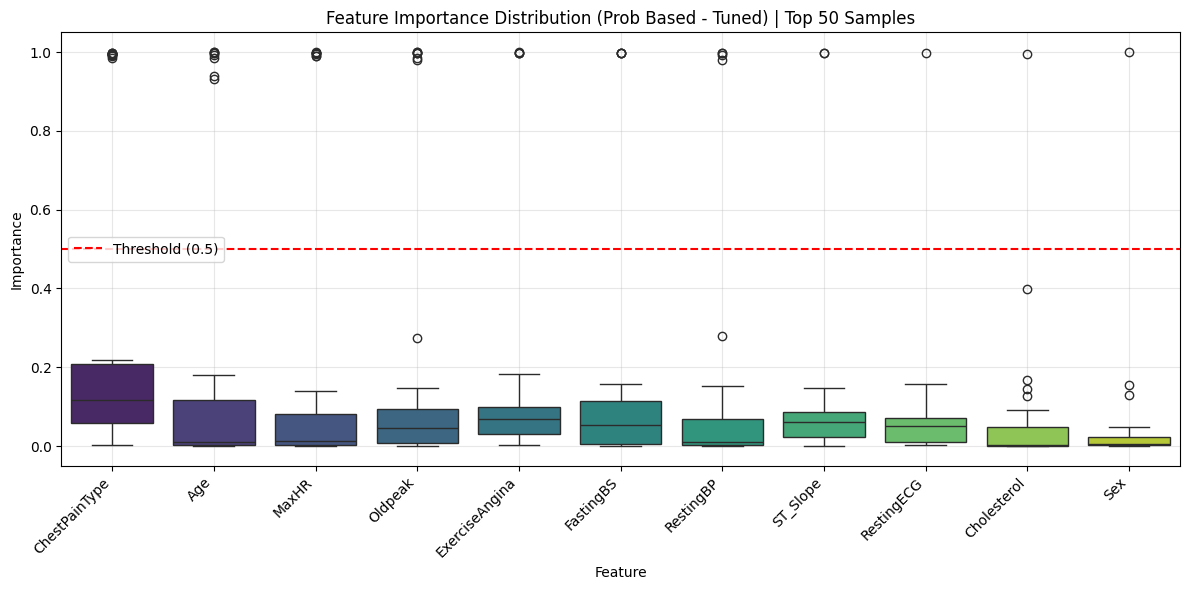

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm

def analyze_prob_distribution_boxplot(model, loader, src_name, num_samples=50):
    """
    튜닝된 Prob 파라미터로 상위 N개 샘플을 분석하여 Box Plot을 그림.
    """
    print(f"=== Analyzing top {num_samples} samples using [Tuned Prob Method] ===")
    
    # 결과를 저장할 리스트
    results = []
    
    # 1. 반복문으로 샘플 분석
    for i in tqdm(range(num_samples)):
        # 튜닝된 파라미터 적용 (L1 규제를 0.05로 낮춤)
        importance, names, _ = explain_cls_prob(
            model, 
            loader=loader, 
            src_name=src_name, 
            sample_idx=i, 
            steps=300,        # Step 증가
            lr=0.05,          # LR 감소
            lambda_l1=0.05,   
            lambda_ent=0.1
        )
        
        # 결과 저장 (Feature 이름 : 중요도 점수)
        for name, score in zip(names, importance):
            results.append({
                "Feature": name,
                "Importance": score
            })

    # 2. 데이터프레임 변환
    df = pd.DataFrame(results)
    
    # 3. 중요도 평균 순으로 정렬 (시각화 예쁘게 하기 위함)
    order = df.groupby("Feature")["Importance"].mean().sort_values(ascending=False).index
    
    # 4. Box Plot 그리기
    plt.figure(figsize=(12, 6))
    sns.boxplot(x="Feature", y="Importance", data=df, order=order, palette="viridis")
    plt.title(f"Feature Importance Distribution (Prob Based - Tuned) | Top {num_samples} Samples")
    plt.xticks(rotation=45, ha='right')
    plt.grid(True, alpha=0.3)
    plt.ylim(-0.05, 1.05) # 0~1 사이 범위 고정
    
    # 0.5 기준선 (Threshold)
    plt.axhline(0.5, color='red', linestyle='--', label='Threshold (0.5)')
    plt.legend()
    plt.tight_layout()
    plt.show()

# --- 실행 ---
# 사용하시는 소스 이름 (예: 'heart')
target_src_name = sources[0] 
target_loader = loaders[target_src_name]

# 50개 샘플에 대해 분석 시작
analyze_prob_distribution_boxplot(model, target_loader, target_src_name, num_samples=50)